<a href="https://www.kaggle.com/code/nobodynub/lung-parallel?scriptVersionId=310802242" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
!pip install -q timm lime grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Section 1: Imports & Configuration

In [2]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight  # ✅ Fix #6
import matplotlib.pyplot as plt
from torchvision import models
from PIL import Image
from tqdm.notebook import tqdm
from skimage import exposure
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries
import timm
import shutil
from pathlib import Path
import torchvision.models as models

import shap

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

# --- GLOBAL SETTINGS ---
NUM_CLASSES = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
print(f"✅ Device: {DEVICE}")

class Config:
    IMG_SIZE = 224        # Model input size
    BATCH_SIZE = 16
    TARGET_CLASS = "Pneumonia-Viral"
    ORIGINAL_DATASET = Path("/kaggle/input/datasets/mohamedasak/chest-x-ray-6-classes-dataset/chest-xray")   # CHANGE THIS
    WORKING_DIR = Path("./working_dataset")

✅ Device: cuda


# Section 2: Data Loading & Split

In [3]:
# ==============================
# CREATE WORKING DATASET (5-CLASS)
# ==============================
ORIGINAL_DATASET = Path("/kaggle/input/datasets/mohamedasak/chest-x-ray-6-classes-dataset/chest-xray")   # CHANGE THIS
WORKING_DIR = Path("./working_dataset")

SPLITS = ["train", "val", "test"]

CLASS_A = "Pneumonia-Bacterial"
CLASS_B = "Pneumonia-Viral"
MERGED_CLASS = "Pneumonia"

# Remove old working dir if exists
if WORKING_DIR.exists():
    shutil.rmtree(WORKING_DIR)

# Copy full dataset into working directory
shutil.copytree(ORIGINAL_DATASET, WORKING_DIR)

print("Dataset copied to working directory.")

# Merge pneumonia classes inside working directory
for split in SPLITS:
    split_path = WORKING_DIR / split
    
    dir_a = split_path / CLASS_A
    dir_b = split_path / CLASS_B
    merged_dir = split_path / MERGED_CLASS
    
    merged_dir.mkdir(parents=True, exist_ok=True)
    
    # Move files from class A
    for img in dir_a.iterdir():
        if img.is_file():
            shutil.move(str(img), merged_dir / img.name)
    
    # Move files from class B
    for img in dir_b.iterdir():
        if img.is_file():
            shutil.move(str(img), merged_dir / img.name)
    
    shutil.rmtree(dir_a)
    shutil.rmtree(dir_b)
    
    print(f"[{split.upper()}] Merged pneumonia classes.")

print("Working dataset ready.")

Dataset copied to working directory.
[TRAIN] Merged pneumonia classes.
[VAL] Merged pneumonia classes.
[TEST] Merged pneumonia classes.
Working dataset ready.


In [4]:
def load_data():
    def get_df(sdir):
        filepaths, labels = [], []
        classes = sorted(os.listdir(sdir))
        for klass in classes:
            classpath = os.path.join(sdir, klass)
            if os.path.isdir(classpath):
                flist = os.listdir(classpath)               
                for f in flist:
                    filepaths.append(os.path.join(classpath, f))
                    labels.append(klass)
        return pd.DataFrame({'filepaths': filepaths, 'labels': labels}), classes
    
    # Load all three splits
    train_df, classes = get_df(os.path.join(Config.WORKING_DIR, 'train'))
    valid_df, _ = get_df(os.path.join(Config.WORKING_DIR, 'val'))
    test_df, _ = get_df(os.path.join(Config.WORKING_DIR, 'test')) # <-- NEW
    
    return train_df, valid_df, test_df, classes # <-- NEW

# Unpack the new test dataframe
train_df, valid_df, test_df, classes = load_data()

# Optional: Print the counts to verify your splits
print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(valid_df)}")
print(f"Testing images: {len(test_df)}")

Training images: 14551
Validation images: 1748
Testing images: 1737


# Section 3: Data Augmentation

In [5]:
class RandomGamma:
    def __init__(self, gamma_range=(0.95, 1.05)):
        self.gamma_range = gamma_range
    def __call__(self, img):
        gamma = random.uniform(*self.gamma_range)
        return T.functional.adjust_gamma(img, gamma)

train_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(7),
    RandomGamma((0.95, 1.05)),
    T.ToTensor(),
])

val_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    T.ToTensor(),
])

# Section 4: Dataset with Dynamic Sampling

In [6]:
class LungDataset(Dataset):
    def __init__(self, real_df, transform=None):
        self.real_df = real_df.reset_index(drop=True)
        self.transform = transform
        self.class_map = {label: i for i, label in enumerate(sorted(self.real_df['labels'].unique()))}
        
    def __len__(self):
        return len(self.real_df)
        
    def __getitem__(self, idx):
        row = self.real_df.iloc[idx]
        img = cv2.imread(row['filepaths'])
        if img is None:     
            raise ValueError(f"Image not found or corrupted: {row['filepaths']}")
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = exposure.equalize_adapthist(img, clip_limit=0.02, kernel_size=(8, 8))
        img = (img * 255).astype(np.uint8)
        
        if self.transform:
            img = self.transform(img)
            
        label = self.class_map[row['labels']]
        return img, label

# Create datasets for all three splits
train_dataset = LungDataset(train_df, transform=train_transforms)
val_dataset = LungDataset(valid_df, transform=val_transforms)
test_dataset = LungDataset(test_df, transform=val_transforms) # <-- NEW

# Create dataloaders for all three splits
train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False) # <-- NEW

# Section 5: Model Helpers (Updated)

In [7]:
class CBAM(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.fc = nn.Sequential(nn.Conv2d(c, c//16, 1), nn.ReLU(), nn.Conv2d(c//16, c, 1))
        self.spatial = nn.Conv2d(2, 1, 7, padding=3)
    def forward(self, x):
        return x * torch.sigmoid(self.fc(nn.AdaptiveAvgPool2d(1)(x))) * torch.sigmoid(self.spatial(torch.cat([x.mean(1,True), x.max(1,True)[0]],1)))

class TransformerEncoder(nn.Module):
    def __init__(self, dim, heads, layers):
        super().__init__()
        self.enc = nn.TransformerEncoder(nn.TransformerEncoderLayer(dim, heads, batch_first=True), layers)
    def forward(self, x): return self.enc(x)

# Section 5: Model Definitions

In [8]:
class ParallelHybrid(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.cnn_stream = nn.Sequential(*list(models.resnet18(pretrained=True).children())[:-1], nn.Flatten())
        self.vit_embed = nn.Conv2d(3, 256, 16, 16)
        self.pos = nn.Parameter(torch.randn(1, 197, 256))
        self.vit = TransformerEncoder(256, 4, 4)
        self.head = nn.Linear(512 + 256, n_classes)
    def forward(self, x):
        c = self.cnn_stream(x)
        v = self.vit_embed(x).flatten(2).transpose(1,2)
        v = torch.cat([torch.zeros(x.size(0),1,256).to(x.device), v], 1) + self.pos
        return self.head(torch.cat([c, self.vit(v)[:,0]], 1))

class CrossAttentionHybrid(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.backbone = nn.Sequential(*list(models.resnet18(pretrained=True).children())[:-2])
        self.proj = nn.Conv2d(512, 256, 1)
        self.query = nn.Parameter(torch.randn(1, 1, 256))
        self.attn = nn.MultiheadAttention(256, 4, batch_first=True)
        self.norm = nn.LayerNorm(256)
        self.dropout = nn.Dropout(0.1)
        self.fc = nn.Linear(256, n_classes)
        
    def forward(self, x):
        k = self.proj(self.backbone(x)).flatten(2).transpose(1,2)
        q = self.query.expand(x.size(0), -1, -1)
        res, _ = self.attn(q, k, k)
        res = self.norm(res + q)
        res = self.dropout(res)
        return self.fc(res.squeeze(1))

class JointEnsemble(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.m1 = models.mobilenet_v2(pretrained=True)
        self.m1.classifier[1] = nn.Linear(1280, n_classes)
        self.vit_embed = nn.Conv2d(3, 256, 16, 16)
        self.vit = TransformerEncoder(256, 4, 4)
        self.head2 = nn.Linear(256, n_classes)
    def forward(self, x):
        v = self.vit_embed(x).flatten(2).transpose(1,2)
        v = self.vit(torch.cat([torch.zeros(x.size(0),1,256).to(x.device), v], 1))
        return (self.m1(x) + self.head2(v[:,0])) / 2

class MobileNet_to_ViT(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.feats = models.mobilenet_v2(pretrained=True).features
        self.proj = nn.Conv2d(1280, 256, 1)
        self.vit = TransformerEncoder(256, 4, 4)
        self.head = nn.Linear(256, n_classes)
        self.cls_token = nn.Parameter(torch.randn(1, 1, 256))
        
    def forward(self, x):
        x = self.proj(self.feats(x)).flatten(2).transpose(1,2)
        cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        return self.head(self.vit(x)[:,0])

In [9]:
# ==================== FIXED SAFER ULTRAHYBRID (384-channel fix) ====================
class SafeUltraHybrid(nn.Module):
    def __init__(self, n_classes=NUM_CLASSES):
        super().__init__()
        
        # ------------------------------------------------------------------
        # 1️⃣ Strong but Stable CNN Backbone (EfficientNet-B3)
        # ------------------------------------------------------------------
        self.backbone = timm.create_model(
            'efficientnet_b3',
            pretrained=True,
            features_only=True
        )
        self.cbam = CBAM(384)                    # ← FIXED: 384 channels
        self.pool = nn.AdaptiveAvgPool2d(1)
        
        # ------------------------------------------------------------------
        # 2️⃣ Lighter & Safer Transformer Stream
        # ------------------------------------------------------------------
        self.vit_embed = nn.Conv2d(3, 256, kernel_size=16, stride=16)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, 256))
        self.pos = nn.Parameter(torch.randn(1, 197, 256))
        
        self.pre_norm = nn.LayerNorm(256)
        self.vit = TransformerEncoder(dim=256, heads=8, layers=4)
        self.post_norm = nn.LayerNorm(256)
        
        # ------------------------------------------------------------------
        # 3️⃣ Projection + Regularized Fusion
        # ------------------------------------------------------------------
        self.proj_cnn = nn.Sequential(
            nn.Linear(384, 512),                 # ← FIXED: 384 channels
            nn.LayerNorm(512),
            nn.SiLU(inplace=True),
            nn.Dropout(0.2)
        )
        self.proj_vit = nn.Sequential(
            nn.Linear(256, 512),
            nn.LayerNorm(512),
            nn.SiLU(inplace=True),
            nn.Dropout(0.2)
        )
        
        self.fusion = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(512, 256),
            nn.SiLU(inplace=True),
            nn.Dropout(0.15),
        )
        self.head = nn.Linear(256, n_classes)

    def forward(self, x):
        # ---------------- CNN STREAM ----------------
        feats = self.backbone(x)[-1]               # [B, 384, 7, 7]
        feats = self.cbam(feats)
        cnn_feat = self.pool(feats).flatten(1)     # [B, 384]
        cnn_proj = self.proj_cnn(cnn_feat)
        
        # ---------------- TRANSFORMER STREAM ----------------
        v = self.vit_embed(x).flatten(2).transpose(1, 2)   # [B, 196, 256]
        cls_tokens = self.cls_token.expand(x.size(0), -1, -1)
        v = torch.cat([cls_tokens, v], dim=1) + self.pos
        v = self.pre_norm(v)
        v = self.vit(v)
        vit_feat = self.post_norm(v[:, 0])
        vit_proj = self.proj_vit(vit_feat)
        
        # ---------------- FUSION ----------------
        fused = torch.cat([cnn_proj, vit_proj], dim=1)
        fused = self.fusion(fused)
        return self.head(fused)

In [10]:
#----------------Pretrained Models------------
#______________Resnet50_______________
def ResNet50_Baseline(n_classes=NUM_CLASSES):

    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    # Replace classifier
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, n_classes)

    return model

#_______________Densenet121______________
def DenseNet121_Baseline(n_classes=NUM_CLASSES):

    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

    # Replace classifier
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, n_classes)

    return model

#___________VIT____________
def ViT_Base_Baseline(n_classes=NUM_CLASSES):

    model = timm.create_model(
        "vit_base_patch16_224",
        pretrained=True,
        num_classes=n_classes
    )

    return model

# Section 6: Loss Function

In [11]:
class_weights_arr = compute_class_weight(
    class_weight='balanced', 
    classes=np.unique(train_df['labels']), 
    y=train_df['labels']
)
class_weights = torch.tensor(class_weights_arr, dtype=torch.float).to(DEVICE)
print(f"⚖️ Computed Class Weights: {class_weights}")

class AsymmetricFocalLoss(nn.Module):
    def __init__(self, gamma_neg=2.5, gamma_pos=1.0, eps=1e-8, class_weights=None):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.eps = eps
        self.class_weights = class_weights
        
    def forward(self, logits, targets):
        probs = torch.softmax(logits, dim=1)
        targets_oh = F.one_hot(targets, num_classes=logits.size(1)).float()
        
        pos_loss = targets_oh * torch.log(probs + self.eps) * ((1 - probs) ** self.gamma_pos)
        neg_loss = (1 - targets_oh) * torch.log(1 - probs + self.eps) * (probs ** self.gamma_neg)
        
        loss = -(pos_loss + neg_loss)
        if self.class_weights is not None:
            loss *= self.class_weights.unsqueeze(0)
            
        return loss.mean()

criterion = AsymmetricFocalLoss(class_weights=class_weights)

⚖️ Computed Class Weights: tensor([1.2041, 1.4196, 1.0896, 0.6047, 1.1193], device='cuda:0')


# Section 7: Training Utilities

In [12]:
def mixup_data(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def predict_tta(model, imgs):
    logits1 = model(imgs)
    logits2 = model(torch.flip(imgs, dims=[3]))
    return (logits1 + logits2) / 2

def evaluate(model, val_loader, criterion):
    """
    Evaluates the model and returns (Validation Loss, Accuracy, Report)
    """
    model.eval()
    val_loss = 0.0
    preds, gts = [], []
    
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            
            # Get logits (using TTA)
            logits = predict_tta(model, imgs)
            
            # Calculate Loss
            loss = criterion(logits, labels)
            val_loss += loss.item()
            
            # Store predictions for report
            preds.append(logits.argmax(1).cpu())
            gts.append(labels.cpu())
            
    # Calculate averages
    avg_loss = val_loss / len(val_loader)
    preds = torch.cat(preds)
    gts = torch.cat(gts)
    acc = (preds == gts).float().mean().item()
    
    report = classification_report(gts, preds, digits=4, zero_division=0)
    return avg_loss, acc, report

# Section 8: Training Loop (Updated)

In [13]:
MODEL_CONFIGS = {
    # ===============================
    # Hybrid Models
    # ===============================
    "ParallelHybrid": dict(lr=1.5e-4, warmup=5, mixup_start=50),
    #"CrossAttentionHybrid": dict(lr=1.2e-4, warmup=6, mixup_start=50),
    #"JointEnsemble": dict(lr=1e-4, warmup=5, mixup_start=50),
    #"MobileNet_to_ViT": dict(lr=1.3e-4, warmup=5, mixup_start=50),

    # ===============================
    # Proposed Model
    # ===============================
    #"SafeUltraHybrid": dict(lr=1.2e-4, warmup=5, mixup_start=50),

    # ===============================
    # Baselines
    # ===============================
    #"ResNet50": dict(lr=2e-4, warmup=4, mixup_start=50),
    #"DenseNet121": dict(lr=1.8e-4, warmup=4, mixup_start=50),
    #"ViT_Base": dict(lr=8e-5, warmup=6, mixup_start=50),
}

def train_model(model, model_name, train_loader, val_loader, epochs=15):
    cfg = MODEL_CONFIGS[model_name]
    model = model.to(DEVICE)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    # Initialize History
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    best_acc = 0
    best_report = ""
    
    print(f"\n🚀 STARTING TRAINING: {model_name}")
    print(f"{'='*40}")
    
    for epoch in range(epochs):
        model.train()
                
        running_loss = 0
        correct_train = 0
        total_train = 0
        
        loop = tqdm(train_loader, desc=f"Ep {epoch+1}/{epochs}", leave=False)
        
        for imgs, labels in loop:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            
            # Mixup
            if epoch >= cfg["mixup_start"]:
                imgs, y_a, y_b, lam = mixup_data(imgs, labels)
                logits = model(imgs)
                loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)
            else:
                logits = model(imgs)
                loss = criterion(logits, labels)
                
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total_train += labels.size(0)
            
            # Acc calculation (Approx for mixup)
            if epoch >= cfg["mixup_start"]:
                 correct_train += (lam * predicted.eq(y_a.data).cpu().sum().float() + 
                                   (1 - lam) * predicted.eq(y_b.data).cpu().sum().float())
            else:
                 correct_train += (predicted == labels).sum().item()

            loop.set_postfix(loss=loss.item())
            
        scheduler.step()
        
        # --- METRICS ---
        epoch_train_loss = running_loss / len(train_loader)
        epoch_train_acc = 100 * correct_train / total_train
        
        # Pass criterion to evaluate to get Val Loss
        val_loss, val_acc, report = evaluate(model, val_loader, criterion)
        val_acc_percent = val_acc * 100
        
        # Store History
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(val_acc_percent)
        
        if val_acc > best_acc:
            best_acc = val_acc
            best_report = report
            
        # --- SEPARATE PRINTS ---
        print(f"\n[{model_name}] Epoch {epoch+1}/{epochs}")
        print(f"  • Train Loss: {epoch_train_loss:.4f}")
        print(f"  • Val Loss:   {val_loss:.4f}")
        print(f"  • Train Acc:  {epoch_train_acc:.2f}%")
        print(f"  • Val Acc:    {val_acc_percent:.2f}%")
        print(f"{'-'*20}")
        
    print(f"\n==== BEST REPORT ({model_name}) ====\n")
    print(best_report)
    
    return history

# Section 9: Execution

In [14]:
experiment_history = {}

models_dict = {

    # ===============================
    # Hybrid Models
    # ===============================
    "ParallelHybrid": ParallelHybrid(NUM_CLASSES),
    #"CrossAttentionHybrid": CrossAttentionHybrid(NUM_CLASSES),
    #"JointEnsemble": JointEnsemble(NUM_CLASSES),
    #"MobileNet_to_ViT": MobileNet_to_ViT(NUM_CLASSES),

    # ===============================
    # Proposed Model
    # ===============================
    #"SafeUltraHybrid": SafeUltraHybrid(NUM_CLASSES),

    # ===============================
    # Baseline Pretrained Models
    # ===============================
    #"ResNet50": ResNet50_Baseline(NUM_CLASSES),
    #"DenseNet121": DenseNet121_Baseline(NUM_CLASSES),
    #"ViT_Base": ViT_Base_Baseline(NUM_CLASSES),
}



for name, model in models_dict.items():
    experiment_history[name] = train_model(model, name, train_loader, val_loader)

for name, model in models_dict.items():
    print(f"==================== Model: {name} ====================")

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    # 3. Print the counts
    print("-" * 50)
    print(f"Total Parameters:     {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print("\n\n")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]



🚀 STARTING TRAINING: ParallelHybrid


Ep 1/15:   0%|          | 0/909 [00:00<?, ?it/s]

...


[ParallelHybrid] Epoch 13/15
  • Train Loss: 0.0012
  • Val Loss:   0.0139
  • Train Acc:  99.83%
  • Val Acc:    97.94%
--------------------


Ep 14/15:   0%|          | 0/909 [00:00<?, ?it/s]


[ParallelHybrid] Epoch 14/15
  • Train Loss: 0.0010
  • Val Loss:   0.0150
  • Train Acc:  99.80%
  • Val Acc:    97.88%
--------------------


Ep 15/15:   0%|          | 0/909 [00:00<?, ?it/s]


[ParallelHybrid] Epoch 15/15
  • Train Loss: 0.0009
  • Val Loss:   0.0135
  • Train Acc:  99.87%
  • Val Acc:    97.83%
--------------------

==== BEST REPORT (ParallelHybrid) ====

              precision    recall  f1-score   support

           0     0.9829    0.9567    0.9696       300
           1     0.9761    0.9800    0.9780       250
           2     0.9637    0.9733    0.9685       300
           3     0.9768    0.9833    0.9801       600
           4     1.0000    1.0000    1.0000       298

    accuracy                         0.9794      1748
   macro avg     0.9799    0.9787    0.9792      1748
weighted avg     0.9795    0.9794    0.9794      1748

==================== Model: ParallelHybrid ====================
--------------------------------------------------
Total Parameters:     16,687,941
Trainable Parameters: 16,687,941





# SECTION 10: FINAL CLASSIFICATION REPORT

In [15]:
def generate_final_reports(models_dict, test_loader):
    print(f"📊 GENERATING FINAL CLASSIFICATION REPORTS (ON UNSEEN TEST DATA)\n")        
    
    for name, model in models_dict.items():
        print(f"\n{'='*20} REPORT: {name} {'='*20}")
        model.eval()
        model.to(DEVICE)                
        
        all_preds = []
        all_labels = []                
        
        with torch.no_grad():      
            for imgs, lbls in tqdm(test_loader, desc=f"Testing {name}", leave=False):
                imgs = imgs.to(DEVICE)                                
                # Use TTA (Test Time Augmentation) for robust metrics
                logits = predict_tta(model, imgs)          
                preds = logits.argmax(1).cpu().numpy()                                
                
                all_preds.extend(preds)
                all_labels.extend(lbls.numpy())
                
        # Print the standard classification report
        print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

generate_final_reports(models_dict, test_loader)

📊 GENERATING FINAL CLASSIFICATION REPORTS (ON UNSEEN TEST DATA)


==================== REPORT: ParallelHybrid ====================


Testing ParallelHybrid:   0%|          | 0/109 [00:00<?, ?it/s]

              precision    recall  f1-score   support

    Covid-19     0.9699    0.9667    0.9683       300
   Emphysema     0.9605    0.9720    0.9662       250
      Normal     0.9550    0.9900    0.9722       300
   Pneumonia     0.9949    0.9750    0.9848       600
Tuberculosis     1.0000    0.9965    0.9983       287

    accuracy                         0.9793      1737
   macro avg     0.9761    0.9800    0.9780      1737
weighted avg     0.9796    0.9793    0.9793      1737



# SECTION 11: SIDE-BY-SIDE TRAINING VISUALIZATION

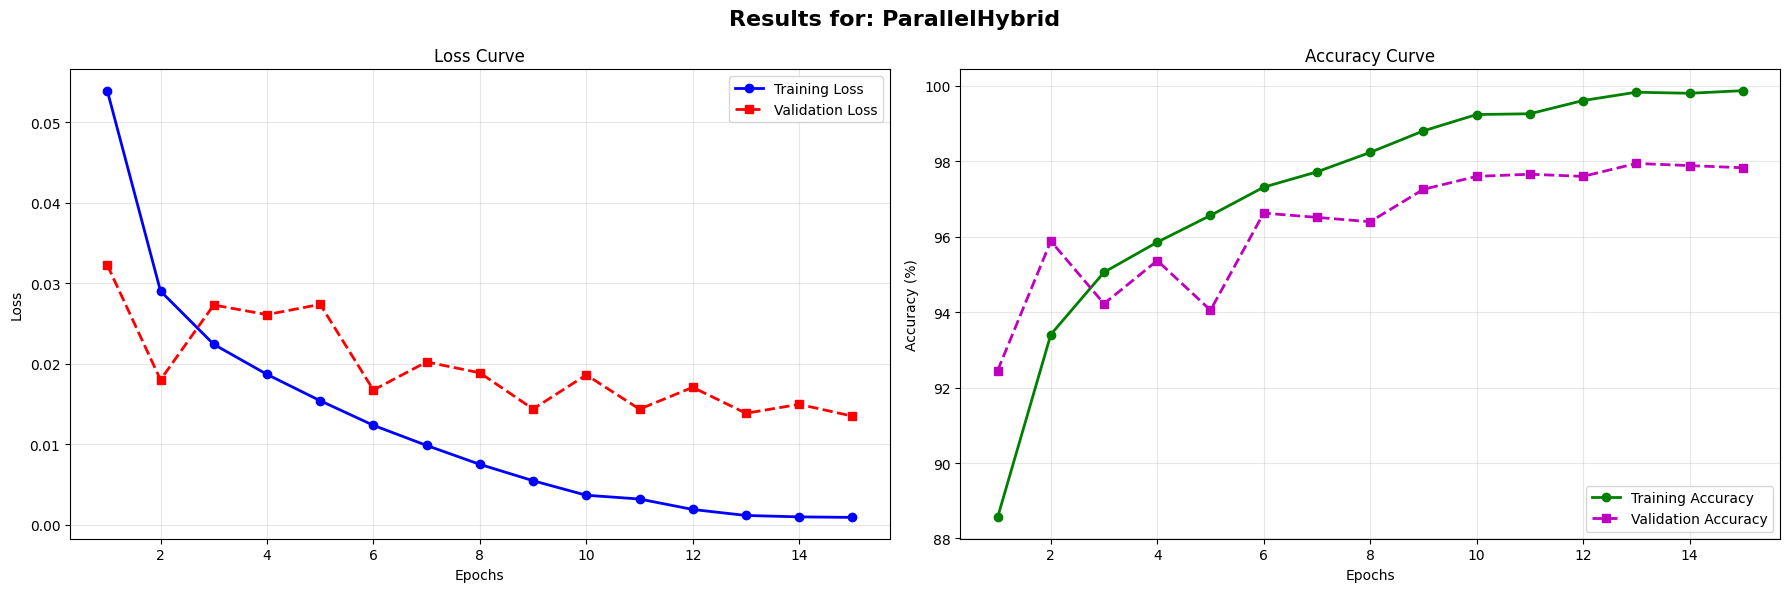

In [16]:
def plot_model_history(history_dict):
    """
    Plots Loss and Accuracy side-by-side for each model.
    Structure: [Loss Plot] | [Accuracy Plot]
    """
    if not history_dict:
        print("⚠️ No history to plot.")
        return

    for model_name, metrics in history_dict.items():
        epochs = range(1, len(metrics['train_loss']) + 1)
        
        # Create 1 row, 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
        fig.suptitle(f"Results for: {model_name}", fontsize=16, fontweight='bold')
        
        # --- LEFT: LOSS ---\
        ax1.plot(epochs, metrics['train_loss'], 'b-o', label='Training Loss', linewidth=2)
        # Note: If val_loss is 0.0 (placeholder), you might want to hide this line
        ax1.plot(epochs, metrics['val_loss'], 'r--s', label='Validation Loss', linewidth=2)
        ax1.set_title("Loss Curve")
        ax1.set_xlabel("Epochs")
        ax1.set_ylabel("Loss")
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # --- RIGHT: ACCURACY ---
        ax2.plot(epochs, metrics['train_acc'], 'g-o', label='Training Accuracy', linewidth=2)
        ax2.plot(epochs, metrics['val_acc'], 'm--s', label='Validation Accuracy', linewidth=2)
        ax2.set_title("Accuracy Curve")
        ax2.set_xlabel("Epochs")
        ax2.set_ylabel("Accuracy (%)")
        ax2.legend(loc='lower right')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

plot_model_history(experiment_history)

# SECTION 12: COMPLETE XAI VISUALIZATION

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:22, 22.39s/it]               


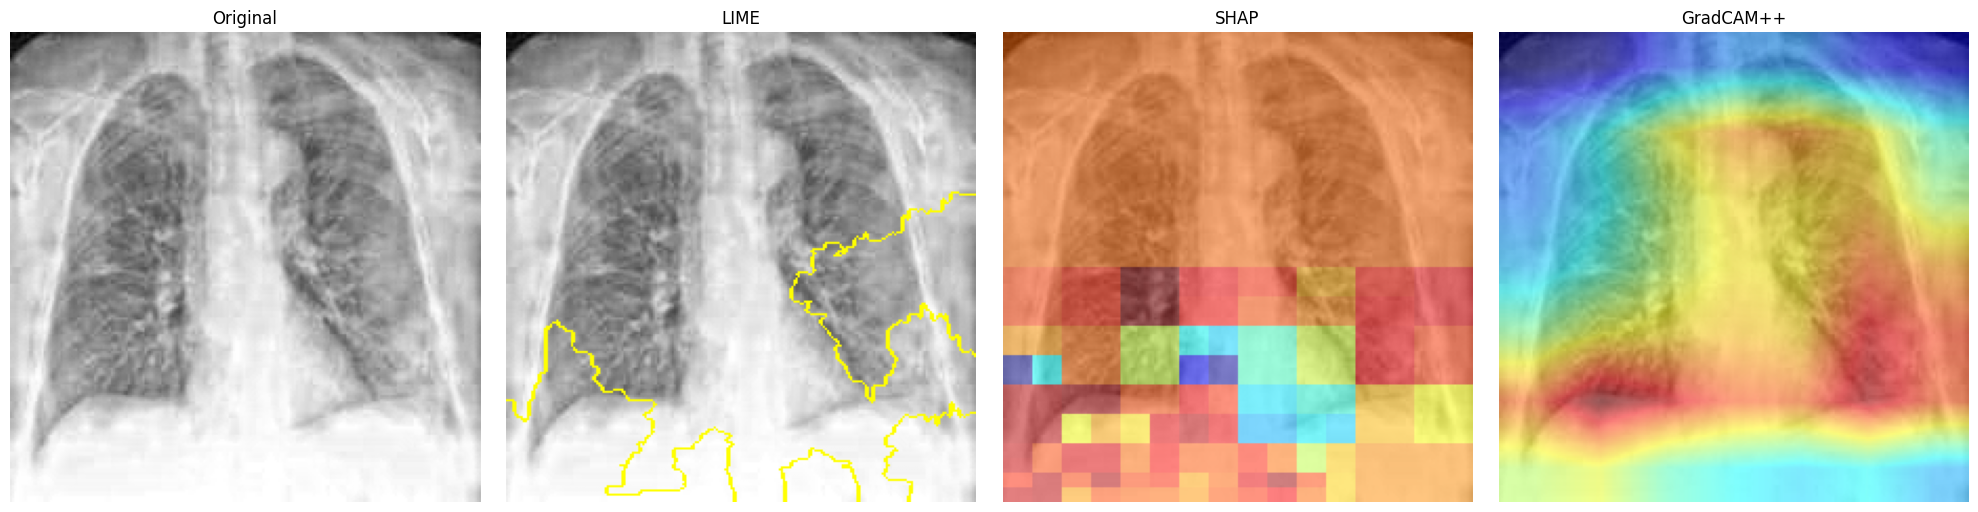

True Label: Covid-19


In [17]:
# 1. Define Target Layers (Where Grad-CAM looks)
XAI_CONFIG = {

    # ===============================
    # Hybrid Models
    # ===============================
    "ParallelHybrid": {"target_layer": lambda m: m.cnn_stream[7]},
    #"CrossAttentionHybrid": {"target_layer": lambda m: m.backbone[7]},
    #"JointEnsemble": {"target_layer": lambda m: m.m1.features[-1]},
    #"MobileNet_to_ViT": {"target_layer": lambda m: m.feats[-1]},

    # ===============================
    # Proposed Model
    # ===============================
    #"SafeUltraHybrid": {"target_layer": lambda m: m.cbam},

    # ===============================
    # Baseline Models
    # ===============================
    #"ResNet50": {"target_layer": lambda m: m.layer4[-1]},
    #"DenseNet121": {"target_layer": lambda m: m.features[-1]},
    #"ViT_Base": {"target_layer": lambda m: m.blocks[-1].norm1}
}

# ------------------------------------------------------------
# LIME prediction function
# ------------------------------------------------------------
def predict_lime(images):

    model.eval()

    imgs = torch.tensor(images).permute(0,3,1,2).float().to(DEVICE)
    imgs = imgs / 255.0

    with torch.no_grad():
        preds = torch.softmax(model(imgs), dim=1)

    return preds.cpu().numpy()


# ------------------------------------------------------------
# SHAP prediction function
# ------------------------------------------------------------
def predict_shap(images):

    imgs = torch.tensor(images).permute(0,3,1,2).float().to(DEVICE)
    imgs = imgs / 255.0

    with torch.no_grad():
        preds = torch.softmax(model(imgs), dim=1)

    return preds.cpu().numpy()


# ------------------------------------------------------------
# Load sample
# ------------------------------------------------------------
images, labels = next(iter(test_loader))

image = images[0].unsqueeze(0).to(DEVICE)
label = labels[0].item()

image_np = images[0].permute(1,2,0).cpu().numpy()
image_np = (image_np - image_np.min())/(image_np.max()-image_np.min())

lime_vis = None
shap_vis = None
gradcam_vis = None

# ------------------------------------------------------------
# LIME
# ------------------------------------------------------------
try:
    explainer = lime_image.LimeImageExplainer()

    lime_exp = explainer.explain_instance(
        (image_np*255).astype(np.uint8),
        predict_lime,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )
    
    lime_img, lime_mask = lime_exp.get_image_and_mask(
        lime_exp.top_labels[0],
        positive_only=True,
        num_features=8,
        hide_rest=False
    )
    
    lime_vis = mark_boundaries(lime_img/255.0, lime_mask)

except Exception as e:
    print("⚠️ LIME failed:", e)

# ------------------------------------------------------------
# SHAP
# ------------------------------------------------------------
try:
    masker = shap.maskers.Image("inpaint_telea", image_np.shape)

    explainer = shap.Explainer(predict_shap, masker)
    
    shap_values = explainer(
        image_np.astype(np.float32)[None,...],
        max_evals=500
    )
    
    shap_map = shap_values.values[0].sum(axis=-1)
    
    shap_map = (shap_map - shap_map.min())/(shap_map.max()-shap_map.min())
    shap_map = cv2.resize(shap_map, (image_np.shape[1], image_np.shape[0]))
    
    shap_vis = cv2.applyColorMap(np.uint8(255*shap_map), cv2.COLORMAP_JET)
    shap_vis = cv2.cvtColor(shap_vis, cv2.COLOR_BGR2RGB)
    shap_vis = shap_vis/255 * 0.5 + image_np * 0.5

except Exception as e:
    print("⚠️ SHAP failed:", e)

# ------------------------------------------------------------
# GradCAM++
# ------------------------------------------------------------
try:
    target_layer = list(XAI_CONFIG.values())[0]["target_layer"](model)

    cam = GradCAMPlusPlus(
        model=model,
        target_layers=[target_layer],
    )
    
    # Predicted class
    with torch.no_grad():
        pred_class = model(image).argmax(dim=1).item()
    
    # Generate CAM
    grayscale_cam = cam(input_tensor=image)[0]
    
    # Overlay heatmap
    gradcam_vis = show_cam_on_image(
        image_np,
        grayscale_cam,
        use_rgb=True
    )

except Exception as e:
    print("⚠️ GradCAM++ failed:", e)
    
# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------
figures = [("Original", image_np)]

if lime_vis is not None:
    figures.append(("LIME", lime_vis))

if shap_vis is not None:
    figures.append(("SHAP", shap_vis))

if gradcam_vis is not None:
    figures.append(("GradCAM++", gradcam_vis))


fig, ax = plt.subplots(1, len(figures), figsize=(5*len(figures),5))

if len(figures) == 1:
    ax = [ax]

for i, (title, img) in enumerate(figures):
    ax[i].imshow(img)
    ax[i].set_title(title)
    ax[i].axis("off")

plt.tight_layout()
plt.show()

print("True Label:", classes[label])